# ⚡ GNN EdgeConv AE — versione LIGHT (GPU locale 4 GB)

**Copia ridotta** di `FINAL_train_gnn_edgeconv_ae.ipynb`, pensata per girare su una GPU locale piccola (GTX 1050, 4 GB) finché il budget Leonardo non torna disponibile. **Non sovrascrive** né il notebook originale né i suoi output (`outputs/gnn_edgeconv_ae_local_light/`).

Modifiche rispetto alla versione completa — **solo** per memoria/tempo, architettura e metodo invariati:
- `BATCH_SIZE`: 256 → **32** (il kNN su 200 tracce è ciò che consuma VRAM; valore sicuro per 4 GB, se hai margine puoi salire a 64);
- subsample: train 40k→**10k**, val/test 20k→**4k**, segnale 40k→**10k**;
- `N_EPOCHS`: 80 → **40**, `PATIENCE`: 12 → **8**.

Loss, kNN, split train/val/test e controllo anti-leakage sono **identici** all'originale. Questo serve a *vedere il modello girare* e avere numeri **indicativi**; i risultati "ufficiali" restano quelli del run completo su GPU grande (Leonardo).

> Se `cuda.is_available()` è `False`: la GPU è "persa" → **riavvia il PC** (o aggiorna i driver). Su CPU questo modello è impraticabile (~2 h/epoca).


# FINAL — GNN EdgeConv Autoencoder

Questo notebook implementa il **GNN Autoencoder finale** usando direttamente il dataset creato dal preprocessing `FINAL`.

Input previsto:

```text
FINAL/processed/repr2_sequences.npz
```

Questo notebook usa **tutte le feature salvate dal preprocessing**:

```text
tutte le jet features presenti in repr2_sequences.npz
tutte le track features presenti in repr2_sequences.npz
```

Non seleziona manualmente un sottoinsieme di feature.  
L'unico controllo è l'anti-leakage check: se trova feature vietate, si ferma.

Schema:

```text
bkg_train -> training QCD
bkg_eval  -> validation QCD + test QCD interno
sig       -> signal EJ
```

Se `repr2_sequences.npz` contiene già un `bkg_test`, lo usa.  
Altrimenti divide `bkg_eval` in:

```text
50% validation QCD
50% test QCD
```

Modello:

```text
track padded + mask
    -> kNN graph sulle tracce
    -> EdgeConv blocks
    -> mean/max pooling
    -> concat con jet features
    -> latent
    -> decoder jet + decoder tracks
```

Anomaly score:

```text
score total = jet reconstruction error + track reconstruction error
```

Salva anche:

```text
score jet
score track
per-feature reconstruction error
permutation importance opzionale
```

## In una frase: il jet come una rete di tracce

Gli altri modelli appiattiscono il jet in un vettore (aggregate) o in una sequenza. Qui invece trattiamo ogni jet per quello che è: **un insieme di tracce che si relazionano tra loro** — cioè un **grafo**. Ogni traccia è un *nodo*; colleghiamo ogni traccia alle sue **k più vicine** (kNN) nel piano η–φ. Una **Graph Neural Network** impara guardando questa struttura di vicinanza: "questa traccia, insieme alle sue vicine, forma un pattern normale (QCD) o strano (EJ)?".

Come gli altri, è un **autoencoder**: comprime il grafo in un vettore latente e poi prova a **ricostruire** le feature di jet e tracce. Allenato solo su QCD, ricostruisce male un EJ → errore alto = anomalia.

| Rappresentazione | Modello | Cosa vede |
|---|---|---|
| aggregate (96) | AE / VAE / NF | un riassunto statistico del jet |
| **grafo kNN di tracce** | **GNN EdgeConv** | **le singole tracce e le loro relazioni** |

### Mappa del notebook
| Sezione | Contenuto |
|---|---|
| 1–6 | Setup, dati, split QCD train/val/test, coordinate kNN |
| 7–8 | Sanity plot, Dataset/DataLoader |
| 9–11 | Il modello EdgeConv (+ tuning), loss |
| 12–13 | Training e curve |
| 14–16 | Anomaly score, ROC/AUC, SIC |
| 17–20 | Controlli fondo, errore per-feature, diagnostiche |
| 21 | Salvataggio |

> train, val e test sono tutti QCD; il segnale EJ entra **solo** nella valutazione finale.


## 1. Import, seed e device

In [1]:
from pathlib import Path
import json
import copy
import math
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch: 2.0.1+cu117
CUDA available: True
CUDA version: 11.7
GPU count: 1
GPU: NVIDIA GeForce GTX 1050 with Max-Q Design
Using device: cuda


## 2. Path e caricamento dataset

In [2]:
CANDIDATE_BASES = [
    Path(".."),
    Path("."),
    Path("FINAL"),
]

PROCESSED_PATH = None

for base in CANDIDATE_BASES:
    candidate = base / "processed" / "repr2_sequences.npz"
    if candidate.exists():
        PROCESSED_PATH = candidate
        PROJECT_BASE = base
        break

if PROCESSED_PATH is None:
    raise FileNotFoundError(
        "Non trovo repr2_sequences.npz. "
        "Controlla che esista in FINAL/processed/repr2_sequences.npz "
        "oppure modifica PROCESSED_PATH manualmente."
    )

OUTPUT_DIR = PROJECT_BASE / "outputs" / "gnn_edgeconv_ae_local_light"
PLOTS_DIR = OUTPUT_DIR / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_BASE:", PROJECT_BASE.resolve())
print("PROCESSED_PATH:", PROCESSED_PATH.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

data = np.load(PROCESSED_PATH, allow_pickle=True)

print("\nKeys in repr2_sequences.npz:")
for k in data.keys():
    arr = data[k]
    print(f"  {k:35s} shape={arr.shape} dtype={arr.dtype}")

PROJECT_BASE: C:\Users\dfraj\OneDrive\Desktop\Master\Adv_ML\Progetto\FINAL
PROCESSED_PATH: C:\Users\dfraj\OneDrive\Desktop\Master\Adv_ML\Progetto\FINAL\processed\repr2_sequences.npz
OUTPUT_DIR: C:\Users\dfraj\OneDrive\Desktop\Master\Adv_ML\Progetto\FINAL\outputs\gnn_edgeconv_ae_local_light

Keys in repr2_sequences.npz:
  X_bkg_train                         shape=(40000, 200, 16) dtype=float32
  mask_bkg_train                      shape=(40000, 200) dtype=bool
  X_bkg_eval                          shape=(40000, 200, 16) dtype=float32
  mask_bkg_eval                       shape=(40000, 200) dtype=bool
  X_sig                               shape=(40000, 200, 16) dtype=float32
  mask_sig                            shape=(40000, 200) dtype=bool
  jet_bkg_train                       shape=(40000, 15) dtype=float32
  jet_bkg_eval                        shape=(40000, 15) dtype=float32
  jet_sig                             shape=(40000, 15) dtype=float32
  track_feature_names                 sh

## 3. Loader robusto delle chiavi

In [3]:
def first_existing_key(data, candidates, required=True):
    for key in candidates:
        if key in data:
            return key
    if required:
        raise KeyError(
            "Nessuna delle chiavi candidate è presente: "
            + ", ".join(candidates)
            + "\nChiavi disponibili: "
            + ", ".join(data.keys())
        )
    return None


track_train_key = first_existing_key(
    data,
    ["X_bkg_train", "X_tracks_bkg_train", "tracks_bkg_train", "X_tracks_train", "X_train"],
)

mask_train_key = first_existing_key(
    data,
    ["mask_bkg_train", "track_mask_bkg_train", "track_mask_train", "mask_train"],
)

jet_train_key = first_existing_key(
    data,
    ["jet_bkg_train", "X_jets_bkg_train", "X_jets_train", "jets_bkg_train", "jets_train"],
)

track_eval_key = first_existing_key(
    data,
    ["X_bkg_eval", "X_tracks_bkg_eval", "tracks_bkg_eval", "X_tracks_eval", "X_eval"],
)

mask_eval_key = first_existing_key(
    data,
    ["mask_bkg_eval", "track_mask_bkg_eval", "track_mask_eval", "mask_eval"],
)

jet_eval_key = first_existing_key(
    data,
    ["jet_bkg_eval", "X_jets_bkg_eval", "X_jets_eval", "jets_bkg_eval", "jets_eval"],
)

track_test_key = first_existing_key(
    data,
    ["X_bkg_test", "X_tracks_bkg_test", "tracks_bkg_test", "X_tracks_test_bkg", "X_test_bkg"],
    required=False,
)

mask_test_key = first_existing_key(
    data,
    ["mask_bkg_test", "track_mask_bkg_test", "track_mask_test_bkg", "mask_test_bkg"],
    required=False,
)

jet_test_key = first_existing_key(
    data,
    ["jet_bkg_test", "X_jets_bkg_test", "X_jets_test_bkg", "jets_bkg_test", "jets_test_bkg"],
    required=False,
)

track_sig_key = first_existing_key(
    data,
    ["X_sig", "X_tracks_sig", "tracks_sig", "X_signal", "X_tracks_signal"],
)

mask_sig_key = first_existing_key(
    data,
    ["mask_sig", "track_mask_sig", "track_mask_signal", "mask_signal"],
)

jet_sig_key = first_existing_key(
    data,
    ["jet_sig", "X_jets_sig", "X_jets_signal", "jets_sig", "jets_signal"],
)

track_feature_key = first_existing_key(
    data,
    ["track_feature_names", "tracks_feature_names"],
    required=False,
)

jet_feature_key = first_existing_key(
    data,
    ["jet_feature_names", "jets_feature_names"],
    required=False,
)

X_tracks_train_raw = np.asarray(data[track_train_key], dtype=np.float32)
mask_train_raw = np.asarray(data[mask_train_key]).astype(bool)
X_jets_train_raw = np.asarray(data[jet_train_key], dtype=np.float32)

X_tracks_eval_raw = np.asarray(data[track_eval_key], dtype=np.float32)
mask_eval_raw = np.asarray(data[mask_eval_key]).astype(bool)
X_jets_eval_raw = np.asarray(data[jet_eval_key], dtype=np.float32)

X_tracks_sig_raw = np.asarray(data[track_sig_key], dtype=np.float32)
mask_sig_raw = np.asarray(data[mask_sig_key]).astype(bool)
X_jets_sig_raw = np.asarray(data[jet_sig_key], dtype=np.float32)

has_bkg_test = track_test_key is not None and mask_test_key is not None and jet_test_key is not None
if has_bkg_test:
    X_tracks_bkg_test_raw = np.asarray(data[track_test_key], dtype=np.float32)
    mask_bkg_test_raw = np.asarray(data[mask_test_key]).astype(bool)
    X_jets_bkg_test_raw = np.asarray(data[jet_test_key], dtype=np.float32)

if track_feature_key is not None:
    track_feature_names = [str(x) for x in data[track_feature_key].tolist()]
else:
    track_feature_names = [f"track_f{i}" for i in range(X_tracks_train_raw.shape[-1])]

if jet_feature_key is not None:
    jet_feature_names = [str(x) for x in data[jet_feature_key].tolist()]
else:
    jet_feature_names = [f"jet_f{i}" for i in range(X_jets_train_raw.shape[-1])]

print("Selected keys:")
print("tracks train:", track_train_key, X_tracks_train_raw.shape)
print("mask train:", mask_train_key, mask_train_raw.shape)
print("jets train:", jet_train_key, X_jets_train_raw.shape)
print("tracks eval:", track_eval_key, X_tracks_eval_raw.shape)
print("mask eval:", mask_eval_key, mask_eval_raw.shape)
print("jets eval:", jet_eval_key, X_jets_eval_raw.shape)

if has_bkg_test:
    print("tracks test bkg:", track_test_key, X_tracks_bkg_test_raw.shape)
    print("mask test bkg:", mask_test_key, mask_bkg_test_raw.shape)
    print("jets test bkg:", jet_test_key, X_jets_bkg_test_raw.shape)
else:
    print("Nessun test background separato trovato: userò split 50/50 di bkg_eval.")

print("tracks sig:", track_sig_key, X_tracks_sig_raw.shape)
print("mask sig:", mask_sig_key, mask_sig_raw.shape)
print("jets sig:", jet_sig_key, X_jets_sig_raw.shape)

print("\nUso TUTTE le jet features:", len(jet_feature_names))
print(jet_feature_names)

print("\nUso TUTTE le track features:", len(track_feature_names))
print(track_feature_names)

Selected keys:
tracks train: X_bkg_train (40000, 200, 16)
mask train: mask_bkg_train (40000, 200)
jets train: jet_bkg_train (40000, 15)
tracks eval: X_bkg_eval (40000, 200, 16)
mask eval: mask_bkg_eval (40000, 200)
jets eval: jet_bkg_eval (40000, 15)
Nessun test background separato trovato: userò split 50/50 di bkg_eval.
tracks sig: X_sig (40000, 200, 16)
mask sig: mask_sig (40000, 200)
jets sig: jet_sig (40000, 15)

Uso TUTTE le jet features: 15
['pt', 'eta', 'mass', 'energy', 'Qw_clusterSoftDrop', 'C2_clusterSoftDrop', 'D2_clusterSoftDrop', 'Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop', 'Tau3_clusterSoftDrop', 'Tau4_clusterSoftDrop', 'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop', 'ECF1_clusterSoftDrop', 'ECF2_clusterSoftDrop']

Uso TUTTE le track features: 16
['pt_log1p', 'd0_log1p', 'z0SinTheta', 'deta', 'dphi', 'qOverP', 'chiSquared', 'radiusOfFirstHit', 'IP3D_signed_d0_significance', 'IP3D_signed_z0_significance', 'numberOfPixelHits', 'numberOfInnermostPixelLayerHits', 'number

## 4. Anti-leakage check

In [4]:
FORBIDDEN_SUBSTRINGS = [
    "isDisplaced",
    "isTagged",
    "salt_pdisp",
    "displacedPtFraction",
    "flavour_label",
    "truthOriginLabel",
    "truthVertexIndex",
    "VSIVertexIndex",
    "truth_dark_pions",
    "truth_stable_non_geant",
    "eventNumber",
    "mcEventWeight",
    "averageInteractionsPerCrossing",
    "actualInteractionsPerCrossing",
    "nPrimaryVertices",
    "isRun3",
]

bad_features = []

for name in jet_feature_names + track_feature_names:
    for bad in FORBIDDEN_SUBSTRINGS:
        if bad.lower() in name.lower():
            bad_features.append(name)

if bad_features:
    print("ERRORE: trovate feature potenzialmente leaky negli input:")
    for f in bad_features:
        print("  ", f)
    raise RuntimeError("Leakage check failed. Rimuovi queste feature dal preprocessing.")
else:
    print("Leakage check OK: nessuna feature vietata trovata negli input.")

Leakage check OK: nessuna feature vietata trovata negli input.


## 5. Pulizia array e split QCD train / val / test

Ripuliamo NaN/inf (→0) e azzeriamo il padding (gli "slot-traccia" vuoti), poi rimuoviamo i jet con **zero tracce valide** (un grafo senza nodi non ha senso). Lo split: se non c'è un test-background dedicato, spezziamo `bkg_eval` **50/50 in val e test** — la val per early-stopping, il **test held-out** solo per la ROC finale. Metodologia pulita: il segnale EJ non entra mai qui.


In [5]:
def finite_array(X, name):
    X = np.asarray(X, dtype=np.float32)
    finite = np.isfinite(X)
    if not finite.all():
        print(f"[WARN] {name}: sostituisco NaN/inf con 0. Non-finite:", np.sum(~finite))
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    return X


def clean_tracks(X, mask, name):
    X = finite_array(X, name).copy()
    X[~mask] = 0.0
    return X


X_jets_train_raw = finite_array(X_jets_train_raw, "X_jets_train_raw")
X_jets_eval_raw = finite_array(X_jets_eval_raw, "X_jets_eval_raw")
X_jets_sig_raw = finite_array(X_jets_sig_raw, "X_jets_sig_raw")

X_tracks_train_raw = clean_tracks(X_tracks_train_raw, mask_train_raw, "X_tracks_train_raw")
X_tracks_eval_raw = clean_tracks(X_tracks_eval_raw, mask_eval_raw, "X_tracks_eval_raw")
X_tracks_sig_raw = clean_tracks(X_tracks_sig_raw, mask_sig_raw, "X_tracks_sig_raw")

if has_bkg_test:
    X_jets_bkg_test_raw = finite_array(X_jets_bkg_test_raw, "X_jets_bkg_test_raw")
    X_tracks_bkg_test_raw = clean_tracks(X_tracks_bkg_test_raw, mask_bkg_test_raw, "X_tracks_bkg_test_raw")


def remove_empty(Xj, Xt, m, label):
    nonempty = m.sum(axis=1) > 0
    print(f"{label}: zero-track jets rimossi {np.sum(~nonempty)} / {len(nonempty)}")
    return Xj[nonempty], Xt[nonempty], m[nonempty]


X_jets_train, X_tracks_train, mask_train = remove_empty(
    X_jets_train_raw, X_tracks_train_raw, mask_train_raw, "train QCD"
)

X_jets_eval, X_tracks_eval, mask_eval = remove_empty(
    X_jets_eval_raw, X_tracks_eval_raw, mask_eval_raw, "eval QCD"
)

X_jets_sig, X_tracks_sig, mask_sig = remove_empty(
    X_jets_sig_raw, X_tracks_sig_raw, mask_sig_raw, "signal EJ"
)

if has_bkg_test:
    X_jets_bkg_test, X_tracks_bkg_test, mask_bkg_test = remove_empty(
        X_jets_bkg_test_raw, X_tracks_bkg_test_raw, mask_bkg_test_raw, "test QCD"
    )
    X_jets_val, X_tracks_val, mask_val = X_jets_eval, X_tracks_eval, mask_eval
else:
    idx_eval = np.arange(X_jets_eval.shape[0])
    idx_val, idx_bkg_test = train_test_split(
        idx_eval,
        test_size=0.5,
        random_state=SEED,
        shuffle=True,
    )

    X_jets_val = X_jets_eval[idx_val]
    X_tracks_val = X_tracks_eval[idx_val]
    mask_val = mask_eval[idx_val]

    X_jets_bkg_test = X_jets_eval[idx_bkg_test]
    X_tracks_bkg_test = X_tracks_eval[idx_bkg_test]
    mask_bkg_test = mask_eval[idx_bkg_test]

print("\nFinal splits:")
print("train QCD:", X_jets_train.shape, X_tracks_train.shape, mask_train.shape)
print("val QCD:", X_jets_val.shape, X_tracks_val.shape, mask_val.shape)
print("test QCD:", X_jets_bkg_test.shape, X_tracks_bkg_test.shape, mask_bkg_test.shape)
print("signal EJ:", X_jets_sig.shape, X_tracks_sig.shape, mask_sig.shape)

n_jet_features = X_jets_train.shape[-1]
n_track_features = X_tracks_train.shape[-1]
max_tracks = X_tracks_train.shape[1]

print("\nn_jet_features:", n_jet_features)
print("n_track_features:", n_track_features)
print("max_tracks:", max_tracks)

train QCD: zero-track jets rimossi 0 / 40000
eval QCD: zero-track jets rimossi 0 / 40000
signal EJ: zero-track jets rimossi 0 / 40000

Final splits:
train QCD: (40000, 15) (40000, 200, 16) (40000, 200)
val QCD: (20000, 15) (20000, 200, 16) (20000, 200)
test QCD: (20000, 15) (20000, 200, 16) (20000, 200)
signal EJ: (40000, 15) (40000, 200, 16) (40000, 200)

n_jet_features: 15
n_track_features: 16
max_tracks: 200


In [6]:
# === [LIGHT] Sottocampionamento per GPU locale (4 GB) ===
# Non presente nella versione completa: riduce il numero di jet
# per stare in VRAM ed entro tempi brevi. Architettura e metodo invariati.
LIGHT_MAX_TRAIN = 10000
LIGHT_MAX_BG    = 4000    # per val e per test (ciascuno)
LIGHT_MAX_SIG   = 10000

def _light_sub(Xj, Xt, m, n, seed):
    if len(Xj) <= n:
        return Xj, Xt, m
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(Xj), size=n, replace=False)
    return Xj[idx], Xt[idx], m[idx]

X_jets_train, X_tracks_train, mask_train = _light_sub(X_jets_train, X_tracks_train, mask_train, LIGHT_MAX_TRAIN, 1)
X_jets_val,   X_tracks_val,   mask_val   = _light_sub(X_jets_val,   X_tracks_val,   mask_val,   LIGHT_MAX_BG, 2)
X_jets_bkg_test, X_tracks_bkg_test, mask_bkg_test = _light_sub(X_jets_bkg_test, X_tracks_bkg_test, mask_bkg_test, LIGHT_MAX_BG, 3)
X_jets_sig,   X_tracks_sig,   mask_sig   = _light_sub(X_jets_sig,   X_tracks_sig,   mask_sig,   LIGHT_MAX_SIG, 4)

print("[LIGHT] dopo subsample -> train:", X_jets_train.shape[0],
      "| val:", X_jets_val.shape[0], "| test:", X_jets_bkg_test.shape[0],
      "| sig:", X_jets_sig.shape[0])


[LIGHT] dopo subsample -> train: 10000 | val: 4000 | test: 4000 | sig: 10000


## 6. Coordinate per il grafo kNN

Il modello usa **tutte** le feature di traccia come attributi dei nodi, ma per **costruire gli archi** (chi è "vicino a chi") servono delle coordinate. Il flag **`KNN_SPACE`** sceglie lo spazio:
- `"etaphi"` (default) → **(Δη, Δφ)**: collega tracce spazialmente vicine nel rivelatore (struttura di sub-jet);
- `"impact"` → **(IP3D d0 sig, IP3D z0 sig)**: le tracce dello **stesso vertice displaced** finiscono vicine — è lo spazio **fisicamente più motivato per gli Emerging Jets**.

Per provare lo spazio dei parametri d'impatto basta cambiare `KNN_SPACE = "impact"` nella cella sotto (le feature sono già dentro `repr2`). È un cambio di modello → verificane l'effetto sull'AUC con un run; di default restiamo su η–φ, scelta standard e sicura.


In [7]:
# Il GNN usa tutte le track features nell'encoder.
# Per costruire il grafo kNN, però, servono delle coordinate (2D) per decidere i vicini.

def find_feature_index(names, candidates):
    lower = [n.lower() for n in names]
    for cand in candidates:
        cand_l = cand.lower()
        for i, name in enumerate(lower):
            if name == cand_l or cand_l in name:
                return i
    return None

# --- Spazio in cui costruire il grafo kNN -------------------------------------
# "etaphi" -> (deta, dphi): tracce vicine nel rivelatore (struttura di sub-jet). DEFAULT.
# "impact" -> (IP3D d0 sig, IP3D z0 sig): le tracce dello stesso vertice displaced
#             finiscono vicine -> spazio fisicamente più motivato per gli Emerging Jets.
# Per cambiare spazio basta QUESTA riga (le feature sono già presenti in repr2):
KNN_SPACE = "etaphi"   # <- metti "impact" per usare lo spazio dei parametri d'impatto
# -----------------------------------------------------------------------------

if KNN_SPACE == "impact":
    idx_a = find_feature_index(track_feature_names, ["IP3D_signed_d0_significance", "d0_significance", "d0_sig"])
    idx_b = find_feature_index(track_feature_names, ["IP3D_signed_z0_significance", "z0_significance", "z0_sig"])
else:  # "etaphi"
    idx_a = find_feature_index(track_feature_names, ["deta", "delta_eta"])
    idx_b = find_feature_index(track_feature_names, ["dphi", "delta_phi"])

if idx_a is not None and idx_b is not None:
    KNN_COORD_IDX = [idx_a, idx_b]
    print(f"kNN space = '{KNN_SPACE}' -> coord idx {KNN_COORD_IDX} "
          f"({[track_feature_names[i] for i in KNN_COORD_IDX]})")
else:
    KNN_COORD_IDX = [0, 1] if n_track_features >= 2 else [0, 0]
    print(f"ATTENZIONE: coordinate non trovate per KNN_SPACE='{KNN_SPACE}'. Fallback:", KNN_COORD_IDX)
    print("names:", [track_feature_names[i] for i in KNN_COORD_IDX])


kNN space = 'etaphi' -> coord idx [3, 4] (['deta', 'dphi'])


## 7. Sanity plot: numero tracce valide

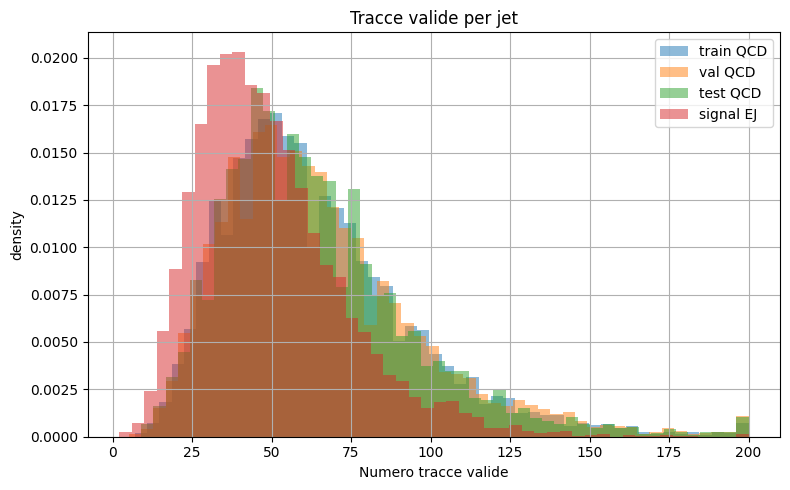

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(mask_train.sum(axis=1), bins=50, density=True, alpha=0.5, label="train QCD")
plt.hist(mask_val.sum(axis=1), bins=50, density=True, alpha=0.5, label="val QCD")
plt.hist(mask_bkg_test.sum(axis=1), bins=50, density=True, alpha=0.5, label="test QCD")
plt.hist(mask_sig.sum(axis=1), bins=50, density=True, alpha=0.5, label="signal EJ")
plt.xlabel("Numero tracce valide")
plt.ylabel("density")
plt.title("Tracce valide per jet")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "valid_tracks_distribution.png", dpi=200)
plt.show()

## 8. Dataset e DataLoader

In [9]:
class JetTrackDataset(Dataset):
    def __init__(self, X_jets, X_tracks, mask):
        self.X_jets = torch.from_numpy(np.asarray(X_jets, dtype=np.float32))
        self.X_tracks = torch.from_numpy(np.asarray(X_tracks, dtype=np.float32))
        self.mask = torch.from_numpy(np.asarray(mask)).bool()

    def __len__(self):
        return self.X_jets.shape[0]

    def __getitem__(self, idx):
        return self.X_jets[idx], self.X_tracks[idx], self.mask[idx]


BATCH_SIZE = 32  # [LIGHT] era 256 (sicuro per 4 GB); se hai margine di VRAM puoi salire a 64

train_loader = DataLoader(
    JetTrackDataset(X_jets_train, X_tracks_train, mask_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    JetTrackDataset(X_jets_val, X_tracks_val, mask_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 313
Val batches: 125


## 9. Il modello: EdgeConv Graph Autoencoder

### Intuizione: le tracce si "parlano" tra loro
Una rete normale guarderebbe ogni traccia da sola. Una **GNN** fa *message passing*: ogni traccia raccoglie informazione dalle sue vicine e aggiorna la propria rappresentazione. Ripetendo per qualche strato, ogni traccia "sa" in che tipo di vicinato si trova — ed è questa struttura locale che distingue un jet QCD da un EJ.

### EdgeConv, passo per passo
Per ogni traccia *i* e ciascuna delle sue *k* vicine *j* (trovate col kNN su Δη–Δφ):
1. si costruisce la **feature dell'arco** combinando la traccia con la *differenza* dalla vicina:
$$e_{ij} = \text{MLP}\big(\,[\,h_i,\; h_j - h_i\,]\,\big)$$
(usare `h_j − h_i` invece di `h_j` rende il blocco sensibile alle *relazioni* relative, non ai valori assoluti);
2. si **aggregano** i contributi delle vicine col **massimo** (operazione simmetrica → non dipende dall'ordine delle tracce):
$$h_i' = \max_{j\in \mathcal{N}(i)} e_{ij} \;+\; \text{residuo}(h_i)$$

Dopo qualche blocco EdgeConv, ogni traccia ha una rappresentazione "consapevole del contesto".

### Da nodi a jet e ritorno (autoencoder)
- **pooling**: si riassume l'intero jet combinando **media** e **massimo** delle rappresentazioni dei nodi (+ un embedding delle feature di jet) → un unico vettore;
- **collo di bottiglia**: lo si comprime nel **latent**;
- **doppio decoder**: dal latent si ricostruiscono sia le **feature di jet** sia le **feature di ogni traccia**.

L'errore di ricostruzione (jet + tracce) è l'anomaly score. Dettagli: `SiLU` come non-linearità, `LayerNorm` per stabilità, e tutto è **mascherato** sul padding (le tracce-fantasma non contribuiscono mai).


In [10]:
def masked_knn_indices(coords, mask, k=8):
    # coords: [B, N, C]
    # mask: [B, N]
    B, N, C = coords.shape

    # Distanze pairwise.
    dist = torch.cdist(coords, coords)

    # Non permettere vicini invalidi.
    invalid_j = ~mask.unsqueeze(1).expand(B, N, N)
    dist = dist.masked_fill(invalid_j, 1e9)

    # Non usare il nodo stesso come vicino.
    eye = torch.eye(N, device=coords.device, dtype=torch.bool).unsqueeze(0)
    dist = dist.masked_fill(eye, 1e9)

    # Per nodi invalidi, i neighbor sono comunque ignorati dopo tramite mask.
    k_eff = min(k, max(N - 1, 1))
    idx = torch.topk(dist, k=k_eff, dim=-1, largest=False).indices

    return idx


def gather_neighbors(h, idx):
    # h: [B, N, D]
    # idx: [B, N, K]
    B, N, D = h.shape
    K = idx.shape[-1]

    idx_expanded = idx.unsqueeze(-1).expand(B, N, K, D)

    h_expanded = h.unsqueeze(1).expand(B, N, N, D)
    neigh = torch.gather(h_expanded, dim=2, index=idx_expanded)

    return neigh


class EdgeConvBlock(nn.Module):
    def __init__(self, hidden_dim, out_dim, dropout=0.05):
        super().__init__()

        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.SiLU(),
        )

        self.residual = nn.Linear(hidden_dim, out_dim) if hidden_dim != out_dim else nn.Identity()

    def forward(self, h, coords, mask, k):
        idx = masked_knn_indices(coords, mask, k=k)
        neigh = gather_neighbors(h, idx)

        h_i = h.unsqueeze(2).expand_as(neigh)
        # feature dell'arco: [traccia, differenza dalla vicina] -> sensibile alle relazioni relative
        edge_feat = torch.cat([h_i, neigh - h_i], dim=-1)

        edge_h = self.edge_mlp(edge_feat)
        # aggregazione simmetrica: massimo sui k vicini (non dipende dall'ordine delle tracce)
        agg = edge_h.max(dim=2).values

        out = agg + self.residual(h)
        out = out * mask.unsqueeze(-1).float()

        return out


class GNNJetTrackAutoencoder(nn.Module):
    def __init__(
        self,
        n_track_features,
        n_jet_features,
        coord_idx,
        hidden_dim=128,
        latent_dim=64,
        n_edge_blocks=3,
        k_neighbors=8,
        dropout=0.05,
    ):
        super().__init__()

        self.n_track_features = n_track_features
        self.n_jet_features = n_jet_features
        self.coord_idx = coord_idx
        self.k_neighbors = k_neighbors

        self.track_embed = nn.Sequential(
            nn.Linear(n_track_features, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
        )

        self.edge_blocks = nn.ModuleList([
            EdgeConvBlock(hidden_dim, hidden_dim, dropout=dropout)
            for _ in range(n_edge_blocks)
        ])

        self.jet_encoder = nn.Sequential(
            nn.Linear(n_jet_features, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
        )

        # mean pool + max pool + jet embedding
        global_dim = 3 * hidden_dim

        self.to_latent = nn.Sequential(
            nn.Linear(global_dim, 2 * hidden_dim),
            nn.LayerNorm(2 * hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(2 * hidden_dim, latent_dim),
        )

        self.jet_decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, n_jet_features),
        )

        self.track_decoder = nn.Sequential(
            nn.Linear(latent_dim + hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, n_track_features),
        )

    def forward(self, x_jets, x_tracks, mask):
        # x_tracks: [B, N, F]
        # mask: [B, N]
        coords = x_tracks[:, :, self.coord_idx]

        h = self.track_embed(x_tracks)
        h = h * mask.unsqueeze(-1).float()

        for block in self.edge_blocks:
            h = block(h, coords, mask, self.k_neighbors)

        mask_f = mask.unsqueeze(-1).float()
        valid_counts = mask_f.sum(dim=1).clamp_min(1.0)

        # pooling del jet: media + massimo sui nodi validi, poi concatenati con l'embedding del jet
        mean_pool = (h * mask_f).sum(dim=1) / valid_counts

        h_for_max = h.masked_fill(~mask.unsqueeze(-1), -1e9)
        max_pool = h_for_max.max(dim=1).values
        max_pool = torch.where(torch.isfinite(max_pool), max_pool, torch.zeros_like(max_pool))

        jet_h = self.jet_encoder(x_jets)

        latent = self.to_latent(torch.cat([mean_pool, max_pool, jet_h], dim=1))

        jet_reco = self.jet_decoder(latent)

        latent_nodes = latent.unsqueeze(1).expand(-1, x_tracks.shape[1], -1)
        track_reco = self.track_decoder(torch.cat([h, latent_nodes], dim=-1))
        track_reco = track_reco * mask.unsqueeze(-1).float()

        return jet_reco, track_reco, latent

## 10. Loss di ricostruzione (mascherata)

La loss somma due pezzi: l'MSE sulle **feature di jet** e l'MSE sulle **feature di traccia**, quest'ultimo calcolato **solo sulle tracce valide** (il padding è escluso dalla maschera e l'errore è normalizzato per il numero di tracce reali, così jet con poche o tante tracce pesano in modo equo). I due pezzi sono combinati con pesi `JET_WEIGHT` e `TRACK_WEIGHT`.


In [11]:
def masked_track_mse(track_reco, x_tracks, mask, reduction="mean"):
    err = (track_reco - x_tracks) ** 2
    err = err * mask.unsqueeze(-1).float()

    per_event = err.sum(dim=(1, 2)) / (mask.sum(dim=1).float() * x_tracks.shape[-1]).clamp_min(1.0)

    if reduction == "none":
        return per_event
    return per_event.mean()


def jet_mse(jet_reco, x_jets, reduction="mean"):
    per_event = torch.mean((jet_reco - x_jets) ** 2, dim=1)

    if reduction == "none":
        return per_event
    return per_event.mean()


def total_ae_loss(jet_reco, track_reco, x_jets, x_tracks, mask, jet_weight=1.0, track_weight=1.0):
    jet_loss = jet_mse(jet_reco, x_jets)
    track_loss = masked_track_mse(track_reco, x_tracks, mask)

    total = jet_weight * jet_loss + track_weight * track_loss

    return total, jet_loss, track_loss

## 10.1 Quick hyperparameter tuning (solo QCD)

Come per AE/VAE e Normalizing Flow, esploriamo gli iperparametri **senza mai usare il segnale**: alleniamo poche epoche su un sottoinsieme di QCD train e selezioniamo in base alla **loss di ricostruzione su QCD validation**, con una piccola penalità sul divario train↔val (overfitting). Manopole: dimensione del latent, n° di blocchi EdgeConv, k vicini, larghezza nascosta, dropout, learning rate. Vince il `selection_score` più basso, usato poi per il modello finale.

> ⚠️ **Costoso**: il kNN si ricostruisce a ogni forward. Esegui questa sezione **su GPU grande (Leonardo)** mettendo `RUN_GNN_TUNING = True`. In locale lasciala su `False` e usa la config di default.


In [12]:
# ============================================================
# Quick hyperparameter tuning — GNN EdgeConv AE
# Criterio: val reconstruction loss QCD; il segnale EJ non viene mai usato.
# ============================================================
import gc

RUN_GNN_TUNING = False   # METTI True su GPU grande (Leonardo). In locale lascia False.

TUNE_MAX_TRAIN = 6000
TUNE_MAX_VAL   = 4000
TUNE_EPOCHS    = 12
TUNE_PATIENCE  = 4

CANDIDATE_CONFIGS = [
    {"hidden_dim": 96,  "latent_dim": 32, "n_edge_blocks": 2, "k_neighbors": 8,  "dropout": 0.05, "lr": 1e-4, "weight_decay": 1e-5, "batch_size": 128},
    {"hidden_dim": 128, "latent_dim": 48, "n_edge_blocks": 3, "k_neighbors": 8,  "dropout": 0.05, "lr": 1e-4, "weight_decay": 1e-5, "batch_size": 128},
    {"hidden_dim": 128, "latent_dim": 64, "n_edge_blocks": 3, "k_neighbors": 8,  "dropout": 0.05, "lr": 1e-4, "weight_decay": 1e-5, "batch_size": 128},
    {"hidden_dim": 128, "latent_dim": 64, "n_edge_blocks": 4, "k_neighbors": 12, "dropout": 0.07, "lr": 8e-5, "weight_decay": 1e-5, "batch_size": 96},
    {"hidden_dim": 192, "latent_dim": 96, "n_edge_blocks": 4, "k_neighbors": 12, "dropout": 0.10, "lr": 8e-5, "weight_decay": 2e-5, "batch_size": 64},
]

def _gnn_sub(Xj, Xt, m, n, seed):
    if len(Xj) <= n:
        return Xj, Xt, m
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(Xj), size=n, replace=False)
    return Xj[idx], Xt[idx], m[idx]

def _make_tune_loader(Xj, Xt, m, bs, shuffle):
    return DataLoader(JetTrackDataset(Xj, Xt, m), batch_size=int(bs), shuffle=shuffle,
                      num_workers=0, pin_memory=torch.cuda.is_available())

@torch.no_grad()
def _tune_eval(model_t, loader):
    model_t.eval(); tot = 0.0; n = 0
    for xj, xt, mk in loader:
        xj = xj.to(device); xt = xt.to(device); mk = mk.to(device)
        jr, tr, _ = model_t(xj, xt, mk)
        loss, _, _ = total_ae_loss(jr, tr, xj, xt, mk, JET_WEIGHT, TRACK_WEIGHT)
        tot += loss.item() * xj.shape[0]; n += xj.shape[0]
    return tot / max(n, 1)

def _tune_one(cfg, cid, Xj_tr, Xt_tr, m_tr, Xj_vl, Xt_vl, m_vl):
    tl = _make_tune_loader(Xj_tr, Xt_tr, m_tr, cfg["batch_size"], True)
    vl = _make_tune_loader(Xj_vl, Xt_vl, m_vl, cfg["batch_size"], False)
    mdl = GNNJetTrackAutoencoder(
        n_track_features, n_jet_features, KNN_COORD_IDX,
        hidden_dim=cfg["hidden_dim"], latent_dim=cfg["latent_dim"],
        n_edge_blocks=cfg["n_edge_blocks"], k_neighbors=cfg["k_neighbors"],
        dropout=cfg["dropout"]).to(device)
    opt = torch.optim.AdamW(mdl.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    best = np.inf; best_ep = -1; bad = 0
    for ep in range(1, TUNE_EPOCHS + 1):
        mdl.train()
        for xj, xt, mk in tl:
            xj = xj.to(device); xt = xt.to(device); mk = mk.to(device)
            opt.zero_grad()
            jr, tr, _ = mdl(xj, xt, mk)
            loss, _, _ = total_ae_loss(jr, tr, xj, xt, mk, JET_WEIGHT, TRACK_WEIGHT)
            if not torch.isfinite(loss):
                raise RuntimeError("loss non finita")
            loss.backward()
            torch.nn.utils.clip_grad_norm_(mdl.parameters(), 5.0)
            opt.step()
        vloss = _tune_eval(mdl, vl)
        if vloss < best:
            best = vloss; best_ep = ep; bad = 0
        else:
            bad += 1
        print(f"[GNN tune {cid}] ep {ep:02d}/{TUNE_EPOCHS} val={vloss:.6f} best={best:.6f}")
        if bad >= TUNE_PATIENCE:
            break
    tr_final = _tune_eval(mdl, tl)
    gap = max(0.0, best - tr_final)
    sel = best + 0.25 * gap
    n_params = sum(p.numel() for p in mdl.parameters())
    del mdl; gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return {"config_id": cid, **cfg, "n_params": int(n_params), "best_epoch": int(best_ep),
            "val_loss": float(best), "train_loss": float(tr_final),
            "generalization_gap": float(gap), "selection_score": float(sel)}

if RUN_GNN_TUNING:
    Xj_tr, Xt_tr, m_tr = _gnn_sub(X_jets_train, X_tracks_train, mask_train, TUNE_MAX_TRAIN, 1)
    Xj_vl, Xt_vl, m_vl = _gnn_sub(X_jets_val, X_tracks_val, mask_val, TUNE_MAX_VAL, 2)
    _rows = []
    for i, cfg in enumerate(CANDIDATE_CONFIGS, 1):
        print("=" * 70); print(f"CONFIG {i}/{len(CANDIDATE_CONFIGS)}: {cfg}")
        try:
            _rows.append(_tune_one(cfg, i, Xj_tr, Xt_tr, m_tr, Xj_vl, Xt_vl, m_vl))
        except RuntimeError as e:
            print(f"[SKIP {i}] {e}")
    gnn_tuning_df = pd.DataFrame(_rows).sort_values("selection_score").reset_index(drop=True)
    display(gnn_tuning_df)
    gnn_tuning_df.to_csv(OUTPUT_DIR / "gnn_edgeconv_ae_hparam_tuning.csv", index=False)
    BEST_GNN_CONFIG = gnn_tuning_df.iloc[0].to_dict()
    print("\nBEST GNN CONFIG:", BEST_GNN_CONFIG)
else:
    BEST_GNN_CONFIG = None
    print("Tuning GNN disattivato (RUN_GNN_TUNING=False): uso la config di default della sezione 11.")


Tuning GNN disattivato (RUN_GNN_TUNING=False): uso la config di default della sezione 11.


## 11. Crea modello

In [13]:
HIDDEN_DIM = 128
LATENT_DIM = 64
N_EDGE_BLOCKS = 3
K_NEIGHBORS = 8
DROPOUT = 0.05

LR = 1e-4
WEIGHT_DECAY = 1e-5

JET_WEIGHT = 1.0
TRACK_WEIGHT = 1.0

N_EPOCHS = 40  # [LIGHT] era 80
PATIENCE = 8  # [LIGHT] era 12

# Se il tuning (sezione 11.1) ha prodotto una config migliore, usala.
if "BEST_GNN_CONFIG" in globals() and BEST_GNN_CONFIG is not None:
    HIDDEN_DIM    = int(BEST_GNN_CONFIG["hidden_dim"])
    LATENT_DIM    = int(BEST_GNN_CONFIG["latent_dim"])
    N_EDGE_BLOCKS = int(BEST_GNN_CONFIG["n_edge_blocks"])
    K_NEIGHBORS   = int(BEST_GNN_CONFIG["k_neighbors"])
    DROPOUT       = float(BEST_GNN_CONFIG["dropout"])
    LR            = float(BEST_GNN_CONFIG["lr"])
    WEIGHT_DECAY  = float(BEST_GNN_CONFIG["weight_decay"])
    print("Uso la configurazione scelta dal tuning (sezione 11.1).")
else:
    print("Uso la configurazione di default.")

model = GNNJetTrackAutoencoder(
    n_track_features=n_track_features,
    n_jet_features=n_jet_features,
    coord_idx=KNN_COORD_IDX,
    hidden_dim=HIDDEN_DIM,
    latent_dim=LATENT_DIM,
    n_edge_blocks=N_EDGE_BLOCKS,
    k_neighbors=K_NEIGHBORS,
    dropout=DROPOUT,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
)

print(model)
print("Parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Uso la configurazione di default.
GNNJetTrackAutoencoder(
  (track_embed): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): SiLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (5): SiLU()
  )
  (edge_blocks): ModuleList(
    (0-2): 3 x EdgeConvBlock(
      (edge_mlp): Sequential(
        (0): Linear(in_features=256, out_features=128, bias=True)
        (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (2): SiLU()
        (3): Dropout(p=0.05, inplace=False)
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (6): SiLU()
      )
      (residual): Identity()
    )
  )
  (jet_encoder): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_af

## 12. Addestramento (solo QCD)

Stesso schema degli altri modelli: per ogni batch forward → loss → backward → step. **AdamW**, **ReduceLROnPlateau** sulla val-loss, **clip dei gradienti** e controllo `isfinite`, **early stopping** sulla val-loss (a fine training si ricaricano i pesi della miglior epoca). Si allena solo sul QCD train; la val QCD seleziona il modello senza mai toccare il segnale.


In [14]:
def evaluate_model(model, loader):
    model.eval()

    total_loss = 0.0
    total_jet = 0.0
    total_track = 0.0
    total_items = 0

    with torch.no_grad():
        for x_jets, x_tracks, mask in loader:
            x_jets = x_jets.to(device, non_blocking=True)
            x_tracks = x_tracks.to(device, non_blocking=True)
            mask = mask.to(device, non_blocking=True)

            jet_reco, track_reco, latent = model(x_jets, x_tracks, mask)
            loss, jloss, tloss = total_ae_loss(
                jet_reco,
                track_reco,
                x_jets,
                x_tracks,
                mask,
                jet_weight=JET_WEIGHT,
                track_weight=TRACK_WEIGHT,
            )

            bs = x_jets.shape[0]
            total_loss += loss.item() * bs
            total_jet += jloss.item() * bs
            total_track += tloss.item() * bs
            total_items += bs

    return (
        total_loss / max(total_items, 1),
        total_jet / max(total_items, 1),
        total_track / max(total_items, 1),
    )


history = []
best_val = np.inf
best_epoch = -1
best_state = None
epochs_no_improve = 0

for epoch in range(N_EPOCHS):
    model.train()

    total_loss = 0.0
    total_jet = 0.0
    total_track = 0.0
    total_items = 0

    for x_jets, x_tracks, mask in train_loader:
        x_jets = x_jets.to(device, non_blocking=True)
        x_tracks = x_tracks.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)

        optimizer.zero_grad()

        jet_reco, track_reco, latent = model(x_jets, x_tracks, mask)
        loss, jloss, tloss = total_ae_loss(
            jet_reco,
            track_reco,
            x_jets,
            x_tracks,
            mask,
            jet_weight=JET_WEIGHT,
            track_weight=TRACK_WEIGHT,
        )

        if not torch.isfinite(loss):
            raise RuntimeError("Loss non finita.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        bs = x_jets.shape[0]
        total_loss += loss.item() * bs
        total_jet += jloss.item() * bs
        total_track += tloss.item() * bs
        total_items += bs

    train_loss = total_loss / max(total_items, 1)
    train_jet = total_jet / max(total_items, 1)
    train_track = total_track / max(total_items, 1)

    val_loss, val_jet, val_track = evaluate_model(model, val_loader)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_jet_loss": train_jet,
        "train_track_loss": train_track,
        "val_loss": val_loss,
        "val_jet_loss": val_jet,
        "val_track_loss": val_track,
        "lr": current_lr,
    })

    if val_loss < best_val:
        best_val = val_loss
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch+1:03d}/{N_EPOCHS} | "
        f"train={train_loss:.6f} jet={train_jet:.6f} track={train_track:.6f} | "
        f"val={val_loss:.6f} jet={val_jet:.6f} track={val_track:.6f} | "
        f"best={best_val:.6f} @ {best_epoch} | lr={current_lr:.2e}"
    )

    if epochs_no_improve >= PATIENCE:
        print("Early stopping.")
        break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Loaded best model from epoch {best_epoch} with val loss={best_val:.6f}")

df_history = pd.DataFrame(history)
df_history.to_csv(OUTPUT_DIR / "gnn_edgeconv_ae_training_history.csv", index=False)
print("Saved:", OUTPUT_DIR / "gnn_edgeconv_ae_training_history.csv")

Epoch 001/40 | train=0.487210 jet=0.224219 track=0.262991 | val=0.168239 jet=0.078616 track=0.089623 | best=0.168239 @ 1 | lr=1.00e-04
Epoch 002/40 | train=0.124034 jet=0.060409 track=0.063624 | val=0.077731 jet=0.039286 track=0.038445 | best=0.077731 @ 2 | lr=1.00e-04
Epoch 003/40 | train=0.068151 jet=0.035882 track=0.032269 | val=0.045839 jet=0.024836 track=0.021003 | best=0.045839 @ 3 | lr=1.00e-04
Epoch 004/40 | train=0.045002 jet=0.025049 track=0.019954 | val=0.032153 jet=0.018359 track=0.013794 | best=0.032153 @ 4 | lr=1.00e-04
Epoch 005/40 | train=0.032600 jet=0.018725 track=0.013875 | val=0.022444 jet=0.012809 track=0.009635 | best=0.022444 @ 5 | lr=1.00e-04
Epoch 006/40 | train=0.025060 jet=0.014717 track=0.010343 | val=0.018324 jet=0.010994 track=0.007329 | best=0.018324 @ 6 | lr=1.00e-04
Epoch 007/40 | train=0.019787 jet=0.011744 track=0.008043 | val=0.013567 jet=0.007961 track=0.005605 | best=0.013567 @ 7 | lr=1.00e-04
Epoch 008/40 | train=0.016290 jet=0.009826 track=0.0064

## 13. Training plots

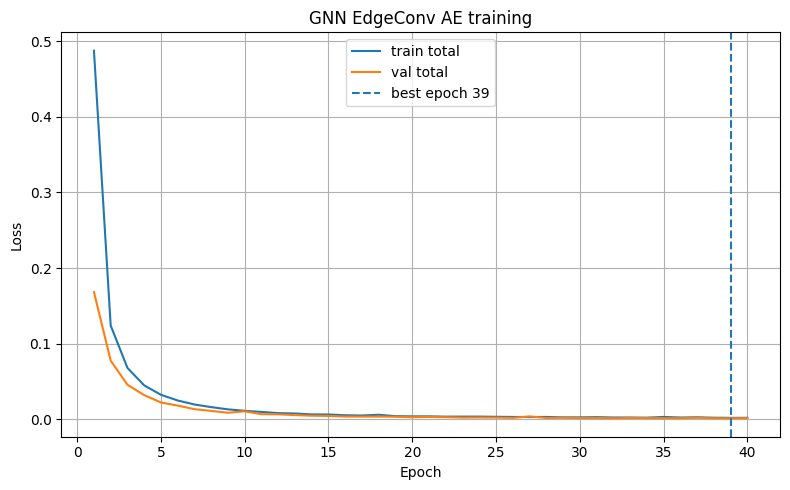

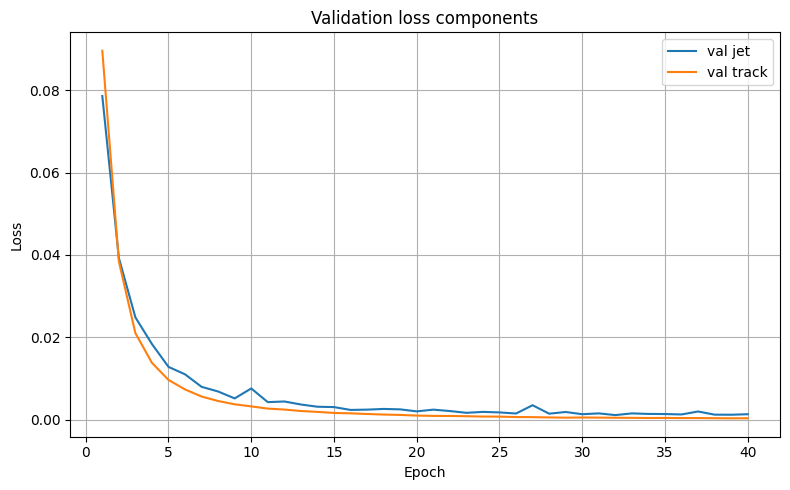

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(df_history["epoch"], df_history["train_loss"], label="train total")
plt.plot(df_history["epoch"], df_history["val_loss"], label="val total")
plt.axvline(best_epoch, linestyle="--", label=f"best epoch {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GNN EdgeConv AE training")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "gnn_edgeconv_ae_training_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(df_history["epoch"], df_history["val_jet_loss"], label="val jet")
plt.plot(df_history["epoch"], df_history["val_track_loss"], label="val track")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation loss components")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "gnn_edgeconv_ae_loss_components.png", dpi=200)
plt.show()

## 14. Anomaly score: errore di ricostruzione

Per ogni jet calcoliamo tre score: **`score_total`** (jet+tracce), **`score_jet`** e **`score_track`** (i due contributi separati). Alto = ricostruito male = anomalo. Teniamo i tre per vedere *dove* sta il potere discriminante (di solito nelle tracce, dove vive la firma displaced degli EJ). Lo score migliore viene scelto guardando l'AUC e usato nei grafici.


In [16]:
@torch.no_grad()
def compute_scores_and_reco(model, X_jets, X_tracks, mask, batch_size=512):
    dataset = JetTrackDataset(X_jets, X_tracks, mask)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model.eval()

    scores_total = []
    scores_jet = []
    scores_track = []
    latents = []

    jet_recos = []
    track_recos = []

    for x_jets, x_tracks, mask_batch in loader:
        x_jets = x_jets.to(device, non_blocking=True)
        x_tracks = x_tracks.to(device, non_blocking=True)
        mask_batch = mask_batch.to(device, non_blocking=True)

        jet_reco, track_reco, latent = model(x_jets, x_tracks, mask_batch)

        s_jet = jet_mse(jet_reco, x_jets, reduction="none")
        s_track = masked_track_mse(track_reco, x_tracks, mask_batch, reduction="none")
        s_total = JET_WEIGHT * s_jet + TRACK_WEIGHT * s_track

        scores_total.append(s_total.cpu().numpy())
        scores_jet.append(s_jet.cpu().numpy())
        scores_track.append(s_track.cpu().numpy())
        latents.append(latent.cpu().numpy())

        jet_recos.append(jet_reco.cpu().numpy())
        track_recos.append(track_reco.cpu().numpy())

    return {
        "score_total": np.concatenate(scores_total),
        "score_jet": np.concatenate(scores_jet),
        "score_track": np.concatenate(scores_track),
        "latent": np.concatenate(latents, axis=0),
        "jet_reco": np.concatenate(jet_recos, axis=0),
        "track_reco": np.concatenate(track_recos, axis=0),
    }


out_train = compute_scores_and_reco(model, X_jets_train, X_tracks_train, mask_train)
out_val = compute_scores_and_reco(model, X_jets_val, X_tracks_val, mask_val)
out_bkg_test = compute_scores_and_reco(model, X_jets_bkg_test, X_tracks_bkg_test, mask_bkg_test)
out_sig = compute_scores_and_reco(model, X_jets_sig, X_tracks_sig, mask_sig)

for score_name in ["score_total", "score_jet", "score_track"]:
    print("\n", score_name)
    for label, out in [
        ("train QCD", out_train),
        ("val QCD", out_val),
        ("test QCD", out_bkg_test),
        ("signal EJ", out_sig),
    ]:
        s = out[score_name]
        print(label, "mean", float(np.mean(s)), "std", float(np.std(s)), "q", np.percentile(s, [1, 50, 99]))


 score_total
train QCD mean 0.0013372687390074134 std 0.0023848910350352526 q [0.00030883 0.00083541 0.00894728]
val QCD mean 0.0014871871098876 std 0.005796569399535656 q [0.00029931 0.00085922 0.01012787]
test QCD mean 0.0013503244845196605 std 0.0030866535380482674 q [0.00030257 0.00082605 0.0092337 ]
signal EJ mean 0.003573057474568486 std 0.009338111616671085 q [0.00037253 0.00155153 0.03089403]

 score_jet
train QCD mean 0.001039167633280158 std 0.002357186283916235 q [0.00010054 0.00053818 0.00853412]
val QCD mean 0.0011819179635494947 std 0.005784251261502504 q [9.85992218e-05 5.50700846e-04 9.72840473e-03]
test QCD mean 0.0010455227456986904 std 0.003060628892853856 q [0.00010083 0.0005307  0.00749468]
signal EJ mean 0.0032242247834801674 std 0.009317629039287567 q [0.00011481 0.0011917  0.03022896]

 score_track
train QCD mean 0.0002981011348310858 std 0.0002211724204244092 q [0.00012961 0.00027112 0.00077722]
val QCD mean 0.00030526917544193566 std 0.00023389789566863328 q 

## 15. Valutazione: ROC, AUC, efficienza

`orient_scores` orienta lo score (alto = signal-like). L'**AUC** misura la separazione QCD vs EJ (0.5 = caso, 1 = perfetto). Riportiamo anche l'**efficienza a mistag fissato** (quanti EJ catturiamo tenendo solo l'X% di QCD più anomalo). Tutto su QCD **test** (held-out) + segnale.


In [17]:
def orient_scores(bg, sig):
    y = np.concatenate([np.zeros_like(bg), np.ones_like(sig)])
    s = np.concatenate([bg, sig])

    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)

    if auc_inv > auc:
        return -bg, -sig, auc_inv, True, auc, auc_inv
    return bg, sig, auc, False, auc, auc_inv


def evaluate_scores(bg, sig, score_name):
    bg_o, sig_o, best_auc, flipped, auc, auc_inv = orient_scores(bg, sig)

    y = np.concatenate([np.zeros_like(bg_o), np.ones_like(sig_o)])
    s = np.concatenate([bg_o, sig_o])

    fpr, tpr, thresholds = roc_curve(y, s)

    rows = []

    for mistag in [0.30, 0.10, 0.05, 0.01, 0.001]:
        threshold = np.quantile(bg_o, 1.0 - mistag)
        eff = np.mean(sig_o >= threshold)
        actual_mistag = np.mean(bg_o >= threshold)

        rows.append({
            "model": "GNN EdgeConv AE",
            "score": score_name,
            "auc": best_auc,
            "raw_auc": auc,
            "auc_inverted": auc_inv,
            "flipped": flipped,
            "mistag_target": mistag,
            "actual_mistag": actual_mistag,
            "signal_efficiency": eff,
            "threshold": threshold,
        })

    return {
        "bg_oriented": bg_o,
        "sig_oriented": sig_o,
        "best_auc": best_auc,
        "auc": auc,
        "auc_inverted": auc_inv,
        "flipped": flipped,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "eff_table": pd.DataFrame(rows),
    }


evals = {}
rows = []

for score_name in ["score_total", "score_jet", "score_track"]:
    ev = evaluate_scores(
        out_bkg_test[score_name],
        out_sig[score_name],
        score_name=score_name,
    )
    evals[score_name] = ev

    rows.append({
        "model": "GNN EdgeConv AE",
        "score": score_name,
        "auc": ev["auc"],
        "auc_inverted": ev["auc_inverted"],
        "best_auc": ev["best_auc"],
        "flipped": ev["flipped"],
    })

df_score_comparison = pd.DataFrame(rows).sort_values("best_auc", ascending=False).reset_index(drop=True)
display(df_score_comparison)

best_score_name = df_score_comparison.iloc[0]["score"]
best_eval = evals[best_score_name]

print("Best score:", best_score_name)
print("Best AUC:", best_eval["best_auc"])

display(best_eval["eff_table"])

,model,score,auc,auc_inverted,best_auc,flipped
0,GNN EdgeConv AE,score_total,0.701344,0.298656,0.701344,False
1,GNN EdgeConv AE,score_jet,0.689019,0.310981,0.689019,False
2,GNN EdgeConv AE,score_track,0.662178,0.337822,0.662178,False


Best score: score_total
Best AUC: 0.7013443125


,model,score,auc,raw_auc,auc_inverted,flipped,mistag_target,actual_mistag,signal_efficiency,threshold
0,GNN EdgeConv AE,score_total,0.701344,0.701344,0.298656,False,0.300,0.300,0.5984,0.001199
1,GNN EdgeConv AE,score_total,0.701344,0.701344,0.298656,False,0.100,0.100,0.3607,0.002310
2,GNN EdgeConv AE,score_total,0.701344,0.701344,0.298656,False,0.050,0.050,0.2569,0.003283
3,GNN EdgeConv AE,score_total,0.701344,0.701344,0.298656,False,0.010,0.010,0.0748,0.009234
4,GNN EdgeConv AE,score_total,0.701344,0.701344,0.298656,False,0.001,0.001,0.0117,0.027419


## 16. Plot ROC e score distributions

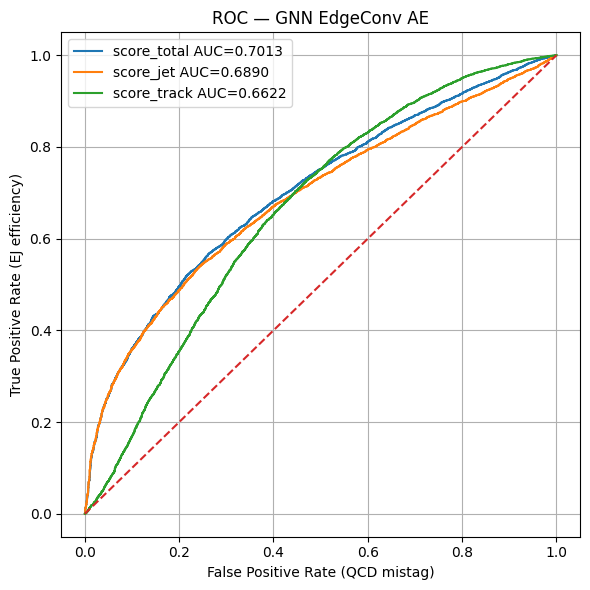

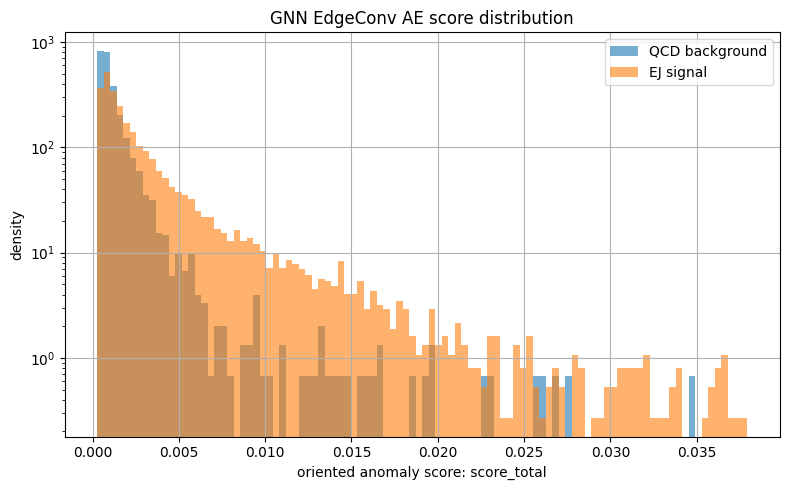

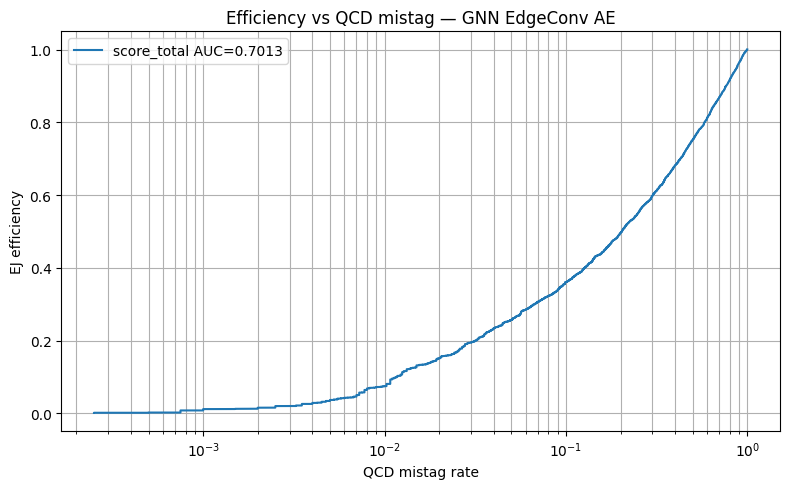

In [18]:
plt.figure(figsize=(6, 6))
for score_name, ev in evals.items():
    plt.plot(ev["fpr"], ev["tpr"], label=f"{score_name} AUC={ev['best_auc']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate (QCD mistag)")
plt.ylabel("True Positive Rate (EJ efficiency)")
plt.title("ROC — GNN EdgeConv AE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "gnn_edgeconv_ae_roc.png", dpi=200)
plt.show()

bg_o = best_eval["bg_oriented"]
sig_o = best_eval["sig_oriented"]

all_scores = np.concatenate([bg_o, sig_o])
lo = np.percentile(all_scores, 0.1)
hi = np.percentile(all_scores, 99.5)

plt.figure(figsize=(8, 5))
plt.hist(bg_o, bins=100, range=(lo, hi), density=True, alpha=0.6, label="QCD background")
plt.hist(sig_o, bins=100, range=(lo, hi), density=True, alpha=0.6, label="EJ signal")
plt.yscale("log")
plt.xlabel(f"oriented anomaly score: {best_score_name}")
plt.ylabel("density")
plt.title("GNN EdgeConv AE score distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "gnn_edgeconv_ae_score_distribution.png", dpi=200)
plt.show()

fpr = best_eval["fpr"]
tpr = best_eval["tpr"]
mask_fpr = fpr > 0

plt.figure(figsize=(8, 5))
plt.plot(fpr[mask_fpr], tpr[mask_fpr], label=f"{best_score_name} AUC={best_eval['best_auc']:.4f}")
plt.xscale("log")
plt.xlabel("QCD mistag rate")
plt.ylabel("EJ efficiency")
plt.title("Efficiency vs QCD mistag — GNN EdgeConv AE")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "gnn_edgeconv_ae_efficiency_vs_mistag.png", dpi=200)
plt.show()

## 16.1 Curva SIC (Significance Improvement Characteristic)

La **SIC** è la metrica standard nei paper di anomaly detection al LHC. Risponde a: *di quanto miglioro la significatività statistica del segnale facendo un taglio sullo score?*
$$\text{SIC}(\varepsilon_S) = \frac{\varepsilon_S}{\sqrt{\varepsilon_B}}$$
con $\varepsilon_S$ = efficienza sul segnale (TPR) e $\varepsilon_B$ = mistag del fondo (FPR). Il **picco** (`SIC_max`) indica la soglia operativa ottimale: es. SIC=3 → significatività triplicata. A differenza dell'AUC (che riassume tutta la curva), la SIC dà il *guadagno fisico reale* a una soglia.


SIC_max = 1.176  (a eps_S=0.281, eps_B=0.0573)  | score: score_total


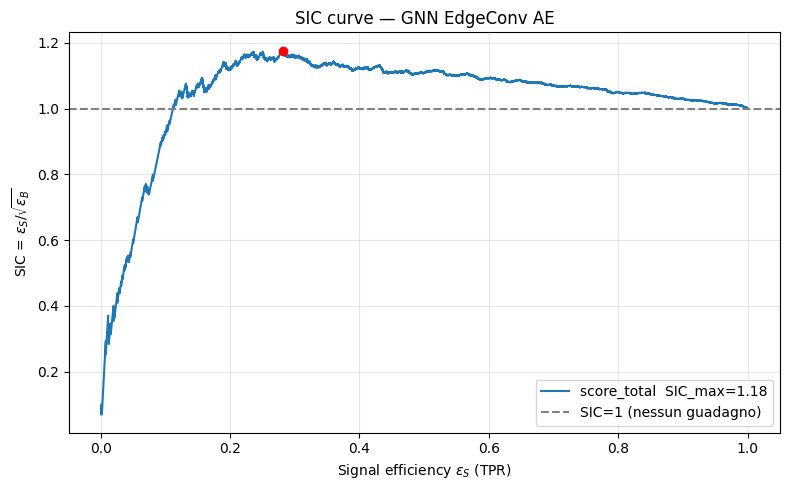

In [19]:
# === SIC: Significance Improvement Characteristic ===
# SIC(eps_S) = eps_S / sqrt(eps_B), calcolata dalla ROC del miglior score.
fpr_sic = best_eval["fpr"]   # eps_B (QCD mistag)
tpr_sic = best_eval["tpr"]   # eps_S (EJ efficiency)

m_sic = fpr_sic > 0          # evita la divisione per zero a mistag nullo
eps_B = fpr_sic[m_sic]
eps_S = tpr_sic[m_sic]
sic = eps_S / np.sqrt(eps_B)

sic_max = float(np.max(sic))
eps_S_at_max = float(eps_S[np.argmax(sic)])
eps_B_at_max = float(eps_B[np.argmax(sic)])

print(f"SIC_max = {sic_max:.3f}  (a eps_S={eps_S_at_max:.3f}, eps_B={eps_B_at_max:.4f})  | score: {best_score_name}")

plt.figure(figsize=(8, 5))
plt.plot(eps_S, sic, label=f"{best_score_name}  SIC_max={sic_max:.2f}")
plt.axhline(1.0, ls="--", color="gray", label="SIC=1 (nessun guadagno)")
plt.scatter([eps_S_at_max], [sic_max], color="red", zorder=5)
plt.xlabel(r"Signal efficiency $\varepsilon_S$ (TPR)")
plt.ylabel(r"SIC = $\varepsilon_S/\sqrt{\varepsilon_B}$")
plt.title("SIC curve — GNN EdgeConv AE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "gnn_edgeconv_ae_sic.png", dpi=200)
plt.show()


## 17. Background consistency checks

,comparison,auc,auc_inverted,best_auc
0,train QCD vs val QCD,0.510987,0.489013,0.510987
1,train QCD vs test QCD,0.498639,0.501361,0.501361
2,val QCD vs test QCD,0.487454,0.512546,0.512546


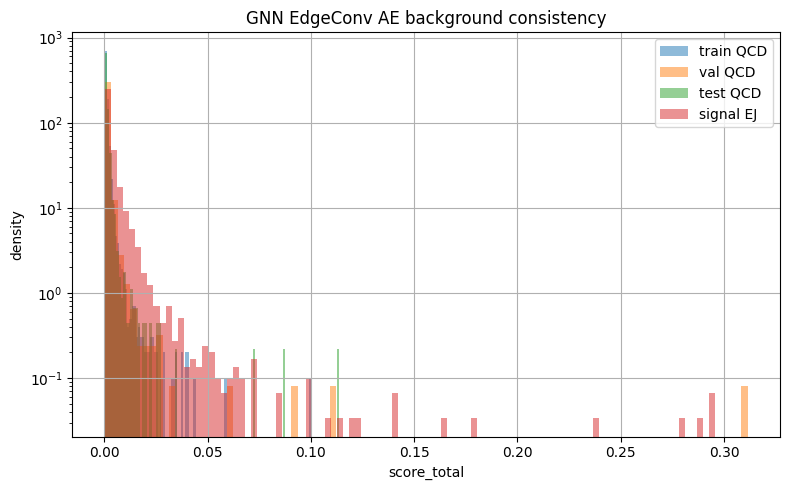

In [20]:
def bg_vs_bg_auc(a, b, name_a, name_b):
    y = np.concatenate([np.zeros_like(a), np.ones_like(b)])
    s = np.concatenate([a, b])

    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)

    return {
        "comparison": f"{name_a} vs {name_b}",
        "auc": auc,
        "auc_inverted": auc_inv,
        "best_auc": max(auc, auc_inv),
    }


bg_checks = pd.DataFrame([
    bg_vs_bg_auc(out_train[best_score_name], out_val[best_score_name], "train QCD", "val QCD"),
    bg_vs_bg_auc(out_train[best_score_name], out_bkg_test[best_score_name], "train QCD", "test QCD"),
    bg_vs_bg_auc(out_val[best_score_name], out_bkg_test[best_score_name], "val QCD", "test QCD"),
])

display(bg_checks)

plt.figure(figsize=(8, 5))
plt.hist(out_train[best_score_name], bins=100, density=True, alpha=0.5, label="train QCD")
plt.hist(out_val[best_score_name], bins=100, density=True, alpha=0.5, label="val QCD")
plt.hist(out_bkg_test[best_score_name], bins=100, density=True, alpha=0.5, label="test QCD")
plt.hist(out_sig[best_score_name], bins=100, density=True, alpha=0.5, label="signal EJ")
plt.yscale("log")
plt.xlabel(best_score_name)
plt.ylabel("density")
plt.title("GNN EdgeConv AE background consistency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "gnn_edgeconv_ae_background_consistency.png", dpi=200)
plt.show()

## 18. Per-feature reconstruction error

,feature_type,feature,mse_bkg,mse_sig,ratio_sig_over_bkg,delta_sig_minus_bkg
0,jet,Tau3_clusterSoftDrop,0.002026,0.019136,9.446114,1.711033e-02
1,jet,Tau2_clusterSoftDrop,0.000954,0.005963,6.249647,5.008774e-03
2,jet,Tau4_clusterSoftDrop,0.001596,0.009750,6.108767,8.154255e-03
3,jet,Tau1_clusterSoftDrop,0.000794,0.002794,3.517943,1.999627e-03
4,jet,mass,0.001154,0.002572,2.228755,1.417860e-03
5,jet,ECF2_clusterSoftDrop,0.001425,0.002389,1.675856,9.633298e-04
6,track,numberOfPixelHits,0.000314,0.000403,1.285301,8.951107e-05
7,jet,eta,0.001450,0.001842,1.269675,3.911604e-04
8,track,IP3D_signed_d0_significance,0.000437,0.000545,1.247671,1.082417e-04
9,track,dphi,0.000305,0.000372,1.220029,6.716923e-05


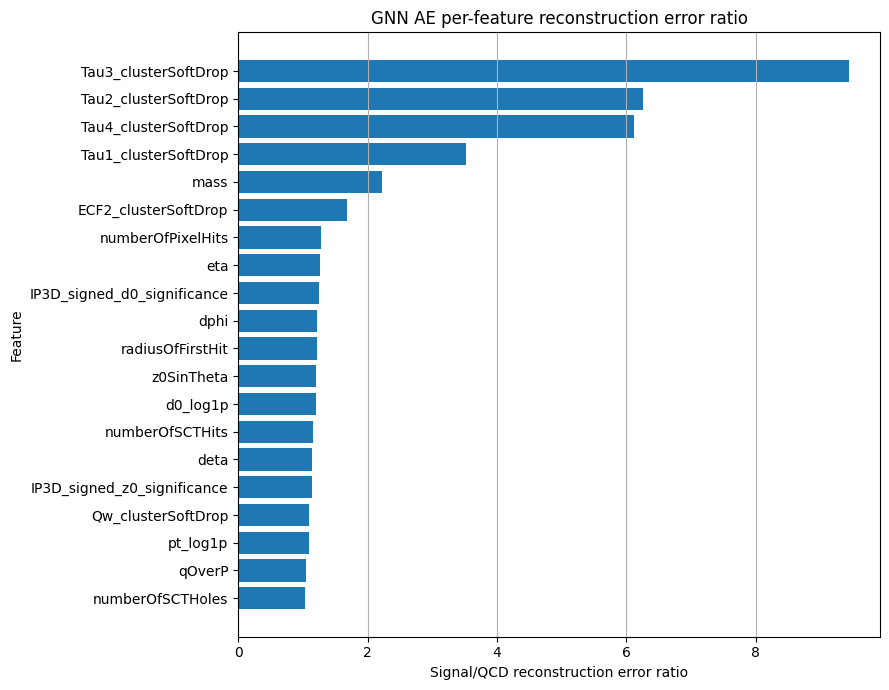

In [21]:
def jet_feature_errors(X_jets, jet_reco):
    return np.mean((jet_reco - X_jets) ** 2, axis=0)


def track_feature_errors(X_tracks, track_reco, mask):
    err = (track_reco - X_tracks) ** 2
    out = []

    for j in range(X_tracks.shape[-1]):
        values = err[:, :, j][mask]
        out.append(np.mean(values) if values.size else np.nan)

    return np.array(out)


jet_err_bkg = jet_feature_errors(X_jets_bkg_test, out_bkg_test["jet_reco"])
jet_err_sig = jet_feature_errors(X_jets_sig, out_sig["jet_reco"])

track_err_bkg = track_feature_errors(X_tracks_bkg_test, out_bkg_test["track_reco"], mask_bkg_test)
track_err_sig = track_feature_errors(X_tracks_sig, out_sig["track_reco"], mask_sig)

df_jet_err = pd.DataFrame({
    "feature_type": "jet",
    "feature": jet_feature_names,
    "mse_bkg": jet_err_bkg,
    "mse_sig": jet_err_sig,
})
df_jet_err["ratio_sig_over_bkg"] = df_jet_err["mse_sig"] / np.maximum(df_jet_err["mse_bkg"], 1e-12)
df_jet_err["delta_sig_minus_bkg"] = df_jet_err["mse_sig"] - df_jet_err["mse_bkg"]

df_track_err = pd.DataFrame({
    "feature_type": "track",
    "feature": track_feature_names,
    "mse_bkg": track_err_bkg,
    "mse_sig": track_err_sig,
})
df_track_err["ratio_sig_over_bkg"] = df_track_err["mse_sig"] / np.maximum(df_track_err["mse_bkg"], 1e-12)
df_track_err["delta_sig_minus_bkg"] = df_track_err["mse_sig"] - df_track_err["mse_bkg"]

df_feature_reco = pd.concat([df_jet_err, df_track_err], ignore_index=True)
df_feature_reco = df_feature_reco.sort_values("ratio_sig_over_bkg", ascending=False).reset_index(drop=True)

df_feature_reco.to_csv(OUTPUT_DIR / "gnn_edgeconv_ae_feature_reconstruction_errors.csv", index=False)

display(df_feature_reco.head(30))

top = df_feature_reco.head(20).iloc[::-1]

plt.figure(figsize=(9, 7))
plt.barh(top["feature"], top["ratio_sig_over_bkg"])
plt.xlabel("Signal/QCD reconstruction error ratio")
plt.ylabel("Feature")
plt.title("GNN AE per-feature reconstruction error ratio")
plt.grid(True, axis="x")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "gnn_edgeconv_ae_feature_reco_ratio.png", dpi=200)
plt.show()

## 19. Diagnostica supervisionata sul latent

In [22]:
# Questa NON è una metrica unsupervised finale.
# Serve solo a capire se il latent contiene informazione discriminante.

X_clf = np.concatenate([out_bkg_test["latent"], out_sig["latent"]], axis=0)
y_clf = np.concatenate([
    np.zeros(out_bkg_test["latent"].shape[0], dtype=np.int64),
    np.ones(out_sig["latent"].shape[0], dtype=np.int64),
])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf,
    y_clf,
    test_size=0.3,
    random_state=SEED,
    stratify=y_clf,
)

clf = LogisticRegression(max_iter=3000)
clf.fit(X_tr, y_tr)

proba = clf.predict_proba(X_te)[:, 1]
auc_latent_logreg = roc_auc_score(y_te, proba)

print("Supervised logistic regression AUC on GNN latent:", auc_latent_logreg)

Supervised logistic regression AUC on GNN latent: 0.9561711111111111


## 20. Permutation importance opzionale

In [24]:
# Può essere lenta: usa pochi eventi per classe.
# Se vuoi saltarla, metti DO_PERMUTATION_IMPORTANCE = False.

DO_PERMUTATION_IMPORTANCE = False  # True per calcolare l'importanza delle feature via permutazione.
MAX_EVENTS_PER_CLASS = 3000

def best_auc_from_scores(bg, sig):
    y = np.concatenate([np.zeros_like(bg), np.ones_like(sig)])
    s = np.concatenate([bg, sig])
    return max(roc_auc_score(y, s), roc_auc_score(y, -s))


def subset_for_importance(Xj_bg, Xt_bg, m_bg, Xj_sig, Xt_sig, m_sig, max_events=3000):
    rng = np.random.default_rng(SEED)

    n_bg = min(max_events, Xj_bg.shape[0])
    n_sig = min(max_events, Xj_sig.shape[0])

    idx_bg = rng.choice(Xj_bg.shape[0], size=n_bg, replace=False)
    idx_sig = rng.choice(Xj_sig.shape[0], size=n_sig, replace=False)

    return (
        Xj_bg[idx_bg].copy(),
        Xt_bg[idx_bg].copy(),
        m_bg[idx_bg].copy(),
        Xj_sig[idx_sig].copy(),
        Xt_sig[idx_sig].copy(),
        m_sig[idx_sig].copy(),
    )


def compute_score_only(model, Xj, Xt, m, score_name, batch_size=512):
    out = compute_scores_and_reco(model, Xj, Xt, m, batch_size=batch_size)
    return out[score_name]


def permutation_importance_gnn(
    model,
    Xj_bg,
    Xt_bg,
    m_bg,
    Xj_sig,
    Xt_sig,
    m_sig,
    jet_feature_names,
    track_feature_names,
    score_name,
):
    rng = np.random.default_rng(SEED)

    base_bg = compute_score_only(model, Xj_bg, Xt_bg, m_bg, score_name)
    base_sig = compute_score_only(model, Xj_sig, Xt_sig, m_sig, score_name)
    base_auc = best_auc_from_scores(base_bg, base_sig)

    rows = []

    # Jet features.
    for j, name in enumerate(jet_feature_names):
        Xj_all = np.concatenate([Xj_bg, Xj_sig], axis=0).copy()
        Xt_all = np.concatenate([Xt_bg, Xt_sig], axis=0).copy()
        m_all = np.concatenate([m_bg, m_sig], axis=0).copy()

        Xj_all[:, j] = rng.permutation(Xj_all[:, j])

        n_bg = Xj_bg.shape[0]
        s_bg = compute_score_only(model, Xj_all[:n_bg], Xt_all[:n_bg], m_all[:n_bg], score_name)
        s_sig = compute_score_only(model, Xj_all[n_bg:], Xt_all[n_bg:], m_all[n_bg:], score_name)

        auc_perm = best_auc_from_scores(s_bg, s_sig)

        rows.append({
            "feature_type": "jet",
            "feature": name,
            "base_auc": base_auc,
            "permuted_auc": auc_perm,
            "importance": base_auc - auc_perm,
        })

    # Track features.
    for j, name in enumerate(track_feature_names):
        Xj_all = np.concatenate([Xj_bg, Xj_sig], axis=0).copy()
        Xt_all = np.concatenate([Xt_bg, Xt_sig], axis=0).copy()
        m_all = np.concatenate([m_bg, m_sig], axis=0).copy()

        tmp = Xt_all[:, :, j].copy()
        valid_values = tmp[m_all].copy()
        valid_values = rng.permutation(valid_values)
        tmp[m_all] = valid_values
        Xt_all[:, :, j] = tmp
        Xt_all[~m_all] = 0.0

        n_bg = Xj_bg.shape[0]
        s_bg = compute_score_only(model, Xj_all[:n_bg], Xt_all[:n_bg], m_all[:n_bg], score_name)
        s_sig = compute_score_only(model, Xj_all[n_bg:], Xt_all[n_bg:], m_all[n_bg:], score_name)

        auc_perm = best_auc_from_scores(s_bg, s_sig)

        rows.append({
            "feature_type": "track",
            "feature": name,
            "base_auc": base_auc,
            "permuted_auc": auc_perm,
            "importance": base_auc - auc_perm,
        })

    return pd.DataFrame(rows).sort_values("importance", ascending=False).reset_index(drop=True)


if DO_PERMUTATION_IMPORTANCE:
    imp_inputs = subset_for_importance(
        X_jets_bkg_test,
        X_tracks_bkg_test,
        mask_bkg_test,
        X_jets_sig,
        X_tracks_sig,
        mask_sig,
        max_events=MAX_EVENTS_PER_CLASS,
    )

    df_importance = permutation_importance_gnn(
        model,
        *imp_inputs,
        jet_feature_names=jet_feature_names,
        track_feature_names=track_feature_names,
        score_name=best_score_name,
    )

    df_importance.to_csv(OUTPUT_DIR / "gnn_edgeconv_ae_permutation_importance.csv", index=False)
    display(df_importance.head(20))

    top = df_importance.head(20).iloc[::-1]

    plt.figure(figsize=(9, 7))
    plt.barh(top["feature"], top["importance"])
    plt.xlabel("AUC drop after permutation")
    plt.ylabel("Feature")
    plt.title("GNN EdgeConv AE permutation importance")
    plt.grid(True, axis="x")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "gnn_edgeconv_ae_permutation_importance.png", dpi=200)
    plt.show()
else:
    df_importance = pd.DataFrame()
    print("Permutation importance skipped.")

Permutation importance skipped.


## 21. Salvataggio finale

In [25]:
results_summary = {
    "model": "GNN EdgeConv AE",
    "best_score": str(best_score_name),
    "auc": float(best_eval["auc"]),
    "auc_inverted": float(best_eval["auc_inverted"]),
    "best_auc": float(best_eval["best_auc"]),
    "flipped": bool(best_eval["flipped"]),
    "auc_latent_logreg": float(auc_latent_logreg),
    "n_jet_features": int(n_jet_features),
    "n_track_features": int(n_track_features),
    "max_tracks": int(max_tracks),
    "hidden_dim": int(HIDDEN_DIM),
    "latent_dim": int(LATENT_DIM),
    "n_edge_blocks": int(N_EDGE_BLOCKS),
    "k_neighbors": int(K_NEIGHBORS),
    "dropout": float(DROPOUT),
    "learning_rate": float(LR),
    "weight_decay": float(WEIGHT_DECAY),
    "batch_size": int(BATCH_SIZE),
    "jet_weight": float(JET_WEIGHT),
    "track_weight": float(TRACK_WEIGHT),
    "best_epoch": int(best_epoch),
    "best_val_loss": float(best_val),
}

for _, row in bg_checks.iterrows():
    key = row["comparison"].replace(" ", "_").replace("vs", "VS")
    results_summary[f"{key}_best_auc"] = float(row["best_auc"])

with open(OUTPUT_DIR / "gnn_edgeconv_ae_config.json", "w") as f:
    json.dump(
        {
            **results_summary,
            "processed_path": str(PROCESSED_PATH),
            "jet_feature_names": jet_feature_names,
            "track_feature_names": track_feature_names,
            "knn_coord_idx": KNN_COORD_IDX,
            "knn_coord_names": [track_feature_names[i] for i in KNN_COORD_IDX],
        },
        f,
        indent=2,
    )

best_eval["eff_table"].to_csv(OUTPUT_DIR / "gnn_edgeconv_ae_results.csv", index=False)
df_score_comparison.to_csv(OUTPUT_DIR / "gnn_edgeconv_ae_score_comparison.csv", index=False)
bg_checks.to_csv(OUTPUT_DIR / "gnn_edgeconv_ae_background_checks.csv", index=False)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": results_summary,
        "jet_feature_names": jet_feature_names,
        "track_feature_names": track_feature_names,
        "knn_coord_idx": KNN_COORD_IDX,
        "history": history,
    },
    OUTPUT_DIR / "gnn_edgeconv_ae_model.pt",
)

np.savez_compressed(
    OUTPUT_DIR / "gnn_edgeconv_ae_scores.npz",
    scores_train_total=out_train["score_total"],
    scores_val_total=out_val["score_total"],
    scores_bkg_test_total=out_bkg_test["score_total"],
    scores_sig_total=out_sig["score_total"],
    scores_train_jet=out_train["score_jet"],
    scores_val_jet=out_val["score_jet"],
    scores_bkg_test_jet=out_bkg_test["score_jet"],
    scores_sig_jet=out_sig["score_jet"],
    scores_train_track=out_train["score_track"],
    scores_val_track=out_val["score_track"],
    scores_bkg_test_track=out_bkg_test["score_track"],
    scores_sig_track=out_sig["score_track"],
    Z_train=out_train["latent"],
    Z_val=out_val["latent"],
    Z_bkg_test=out_bkg_test["latent"],
    Z_sig=out_sig["latent"],
    bg_oriented=best_eval["bg_oriented"],
    sig_oriented=best_eval["sig_oriented"],
    fpr=best_eval["fpr"],
    tpr=best_eval["tpr"],
    thresholds=best_eval["thresholds"],
    jet_feature_names=np.array(jet_feature_names, dtype=object),
    track_feature_names=np.array(track_feature_names, dtype=object),
    best_score_name=np.array(best_score_name, dtype=object),
    auc=np.array(best_eval["auc"], dtype=np.float32),
    auc_inverted=np.array(best_eval["auc_inverted"], dtype=np.float32),
    best_auc=np.array(best_eval["best_auc"], dtype=np.float32),
    auc_latent_logreg=np.array(auc_latent_logreg, dtype=np.float32),
)

print("Saved:")
print(OUTPUT_DIR / "gnn_edgeconv_ae_model.pt")
print(OUTPUT_DIR / "gnn_edgeconv_ae_scores.npz")
print(OUTPUT_DIR / "gnn_edgeconv_ae_results.csv")
print(OUTPUT_DIR / "gnn_edgeconv_ae_score_comparison.csv")
print(OUTPUT_DIR / "gnn_edgeconv_ae_background_checks.csv")
print(OUTPUT_DIR / "gnn_edgeconv_ae_feature_reconstruction_errors.csv")
if DO_PERMUTATION_IMPORTANCE:
    print(OUTPUT_DIR / "gnn_edgeconv_ae_permutation_importance.csv")
print(OUTPUT_DIR / "gnn_edgeconv_ae_config.json")
print("plots:", PLOTS_DIR)

Saved:
outputs\gnn_edgeconv_ae_local_light\gnn_edgeconv_ae_model.pt
outputs\gnn_edgeconv_ae_local_light\gnn_edgeconv_ae_scores.npz
outputs\gnn_edgeconv_ae_local_light\gnn_edgeconv_ae_results.csv
outputs\gnn_edgeconv_ae_local_light\gnn_edgeconv_ae_score_comparison.csv
outputs\gnn_edgeconv_ae_local_light\gnn_edgeconv_ae_background_checks.csv
outputs\gnn_edgeconv_ae_local_light\gnn_edgeconv_ae_feature_reconstruction_errors.csv
outputs\gnn_edgeconv_ae_local_light\gnn_edgeconv_ae_config.json
plots: outputs\gnn_edgeconv_ae_local_light\plots


## Note finali

Questo notebook usa esattamente il dataset del preprocessing finale:

```text
FINAL/processed/repr2_sequences.npz
```

e usa **tutte** le feature presenti lì dentro.  
Non c'è una lista manuale di feature da includere/escludere nel modello, a parte il controllo anti-leakage.

Le feature vengono usate così:

```text
tutte le track features -> input dei nodi GNN
tutte le jet features   -> input globale del jet encoder
deta/dphi, se presenti  -> solo per costruire il grafo kNN
```

Quindi `deta/dphi` non sono le uniche feature usate: servono solo per decidere quali tracce sono vicine nel grafo.